In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from archive.prod.rds import get_rds_connection
from dotenv import load_dotenv
load_dotenv()

True

Number of arXiv categories: 141
Total theorems with categories: 7708421

Top 10 categories:
  primary_category   count
0          math.AP  723838
1          math.CO  662507
2          math.AG  651028
3          math.PR  530995
4          math.NT  495235
5          math.DG  450391
6          math.DS  336880
7          math.FA  308699
8          math.RT  301470
9          math.GR  276700


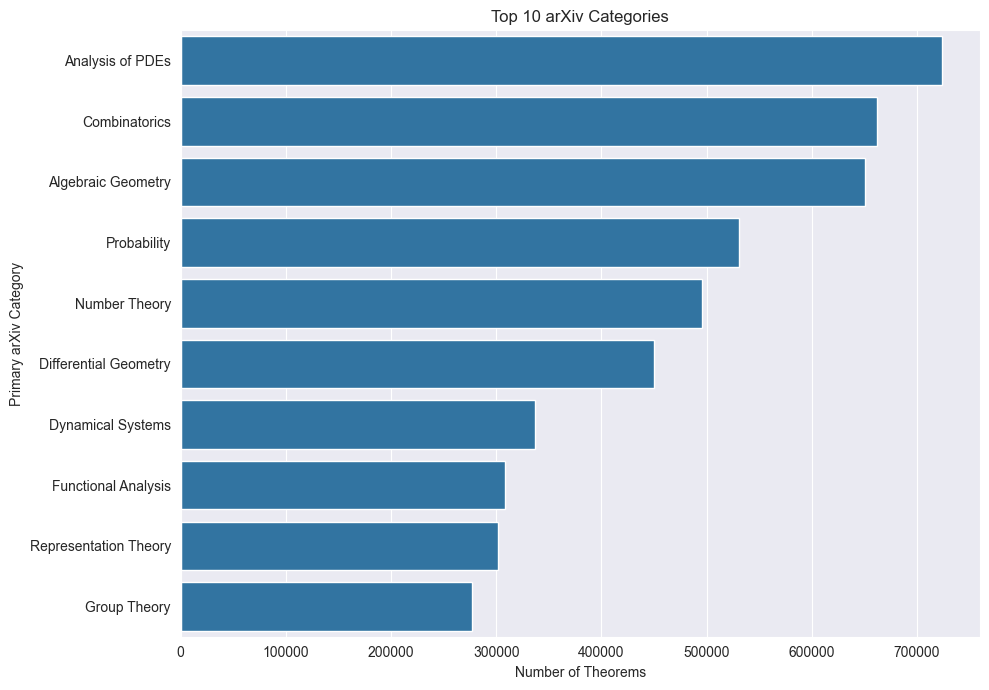

In [4]:
conn = get_rds_connection()
cur = conn.cursor()

ARXIV_FULL_NAMES = {
    "math.AC": "Commutative Algebra",
    "math.AG": "Algebraic Geometry",
    "math.AP": "Analysis of PDEs",
    "math.AT": "Algebraic Topology",
    "math.CA": "Classical Analysis and ODEs",
    "math.CO": "Combinatorics",
    "math.CT": "Category Theory",
    "math.CV": "Complex Variables",
    "math.DG": "Differential Geometry",
    "math.DS": "Dynamical Systems",
    "math.FA": "Functional Analysis",
    "math.GM": "General Mathematics",
    "math.GN": "General Topology",
    "math.GR": "Group Theory",
    "math.GT": "Geometric Topology",
    "math.HO": "History and Overview",
    "math.IT": "Information Theory",
    "math.KT": "K-Theory and Homology",
    "math.LO": "Logic",
    "math.MG": "Metric Geometry",
    "math.MP": "Mathematical Physics",
    "math.NA": "Numerical Analysis",
    "math.NT": "Number Theory",
    "math.OA": "Operator Algebras",
    "math.OC": "Optimization and Control",
    "math.PR": "Probability",
    "math.QA": "Quantum Algebra",
    "math.RA": "Rings and Algebras",
    "math.RT": "Representation Theory",
    "math.SG": "Symplectic Geometry",
    "math.SP": "Spectral Theory",
    "math.ST": "Statistics Theory",
}

query = """
SELECT
    primary_category,
    COUNT(*) AS count
FROM theorem_search_qwen
WHERE
    source = 'arXiv'
    AND primary_category IS NOT NULL
GROUP BY primary_category
ORDER BY count DESC;
"""

cur.execute(query)
rows = cur.fetchall()

df = pd.DataFrame(rows, columns=["primary_category", "count"])
df.head()

print("Number of arXiv categories:", len(df))
print("Total theorems with categories:", df["count"].sum())
print()
print("Top 10 categories:")
df.head(10)

TOP_N = 10

df_plot = df.head(TOP_N).copy()
print(df_plot)
df_plot["full_name"] = df_plot["primary_category"].map(
    lambda c: ARXIV_FULL_NAMES.get(c, c)
)

plt.figure(figsize=(10, 7))
ax = sns.barplot(
    data=df_plot,
    x="count",
    y="full_name"
)

plt.title(f"Top {TOP_N} arXiv Categories")
plt.xlabel("Number of Theorems")
plt.ylabel("Primary arXiv Category")
plt.tight_layout()
plt.show()

cur.close()
conn.close()

In [16]:
conn = get_rds_connection()
cur = conn.cursor()

QUERY = """
SELECT
    embedding,
    primary_category
FROM theorem_search_qwen
WHERE
    source = 'arXiv'
    AND primary_category IN ('math.AG', 'math.PR')
ORDER BY RANDOM()
LIMIT 5000;
"""

cur.execute(QUERY)
rows = cur.fetchall()

cur.close()
conn.close()

X = np.array([row[0] for row in rows])
y = np.array([row[1] for row in rows])

print(X.shape)

(5000, 1024)


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.07890404 0.02803386]
Total explained variance: 0.1069379


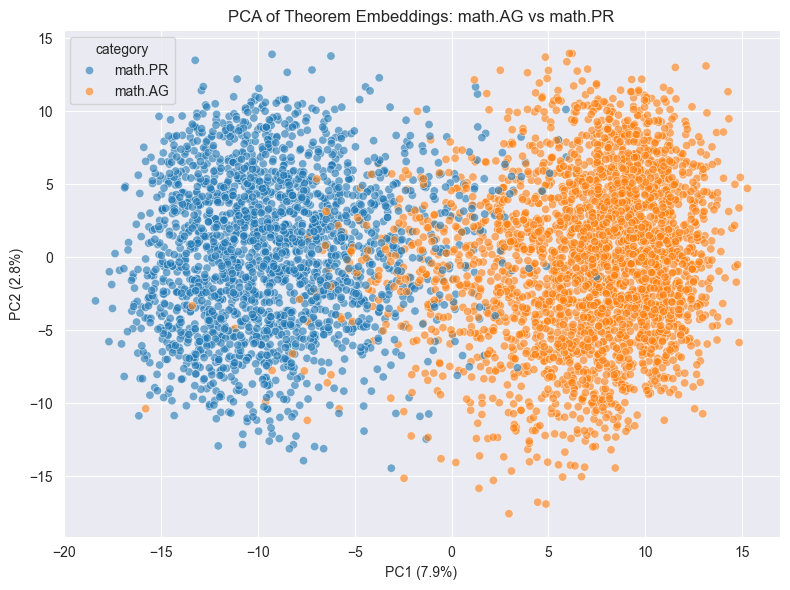

In [18]:
df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "category": y
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="category",
    alpha=0.6
)

plt.title("PCA of Theorem Embeddings: math.AG vs math.PR")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout()
plt.show()

In [ ]:
conn = get_rds_connection()
cur = conn.cursor(name="pca_cursor")

cur.execute("""
    SELECT embedding
    FROM theorem_search_qwen
    WHERE embedding IS NOT NULL
""")

In [ ]:
from sklearn.decomposition import IncrementalPCA
from sklearn.preprocessing import StandardScaler

N_COMPONENTS = 50
BATCH_SIZE = 2048

ipca = IncrementalPCA(
    n_components=N_COMPONENTS,
    batch_size=BATCH_SIZE
)

scaler = StandardScaler(with_mean=True, with_std=True)

batch = cur.fetchmany(BATCH_SIZE)
while batch:
    X = np.array([row[0] for row in batch])
    scaler.partial_fit(X)
    batch = cur.fetchmany(BATCH_SIZE)

cur.scroll(0, mode="absolute")

batch = cur.fetchmany(BATCH_SIZE)

while batch:
    X = np.array([row[0] for row in batch])
    X_scaled = scaler.transform(X)
    ipca.partial_fit(X_scaled)
    batch = cur.fetchmany(BATCH_SIZE)

explained = ipca.explained_variance_ratio_
print("Explained variance (first 10 PCs):")
for i, v in enumerate(explained[:10]):
    print(f"PC{i+1}: {v:.4f}")

print("Cumulative variance (50 PCs):", explained.sum())

In [ ]:
from sklearn.decomposition import PCA

X_sample = X_pca[np.random.choice(len(X_pca), 5000, replace=False)]
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_sample)

In [19]:
conn = get_rds_connection()
cur = conn.cursor()

QUERY = """
SELECT embedding, primary_category
FROM theorem_search_qwen
WHERE source = 'arXiv'
  AND primary_category IS NOT NULL
ORDER BY RANDOM()
LIMIT 5000;
"""

cur.execute(QUERY)
rows = cur.fetchall()

cur.close()
conn.close()

X = np.array([r[0] for r in rows])
y = np.array([r[1] for r in rows])

print(X.shape)

(5000, 1024)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance (50D):", pca.explained_variance_ratio_.sum())

Explained variance (50D): 0.5018061


In [21]:
import umap

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42,
)

X_umap = umap_model.fit_transform(X_pca)

df_umap = pd.DataFrame({
    "x": X_umap[:, 0],
    "y": X_umap[:, 1],
    "category": y
})

df_umap["category_name"] = df_umap["category"].map(
    lambda c: ARXIV_FULL_NAMES.get(c, c)
)

C:\Users\sls70\PycharmProjects\MathCopilot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\sls70\PycharmProjects\MathCopilot\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [1]:
keep = ARXIV_FULL_NAMES.keys()
df_umap_small = df_umap[df_umap["category"].isin(keep)]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_umap_small,
    x="x",
    y="y",
    hue="category",
    alpha=0.5,
    s=18,
    linewidth=0
)
sns.set_style("white")
plt.title("UMAP of Theorem Embeddings (PCA → UMAP)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(
    title="Primary Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

NameError: name 'ARXIV_FULL_NAMES' is not defined